<img src="https://tse2.mm.bing.net/th/id/OIP.seRhrSx-cXcfATaCivVDVwHaEZ?rs=1&pid=ImgDetMain&o=7&rm=3"/>

# Bitcoin Price

In this project, a machine learning-based approach was developed to predict Bitcoin price movements using historical market data. The primary objective was to explore how different regression models perform in forecasting future prices and to evaluate their strengths and limitations.

The dataset includes key financial indicators such as closing price and trading volume. To enhance the model’s predictive capability, additional features such as moving averages and volatility metrics were incorporated. These features help capture market trends, momentum, and price fluctuations over time.

Several machine learning models were tested, including Support Vector Regression (SVR) and other potential algorithms, to compare their predictive performance. The data was preprocessed through normalization and structured as a time series problem, ensuring that past values were used to predict future outcomes.

The model was trained to estimate Bitcoin prices over a future time horizon, and its performance was evaluated using statistical metrics and visual analysis techniques. Various plots, including actual vs predicted values, residual analysis, and feature correlation heatmaps, were used to better understand model behavior and accuracy.


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# 1. VERİ ÇEKME
# Bitcoin verilerini Yahoo Finance üzerinden alıyoruz
ticker = 'BTC-USD'
df = yf.download(ticker, period='1y', interval='1d')


[*********************100%***********************]  1 of 1 completed


In [3]:
# 2. VERİ ÖN İŞLEME VE TAHMİN SÜTUNU
prediction_days = 30
df['Prediction'] = df[['Close']].shift(-prediction_days)

In [4]:
# Bağımsız değişken (X) ve Bağımlı değişken (y)
# X sadece kapanış fiyatlarını içerir
X = np.array(df[['Close']])
X_forecast = X[-prediction_days:] # Geleceği tahmin etmek için kullanacağımız son 30 gün
X = X[:-prediction_days]         # Eğitim için son 30 günü çıkarıyoruz
y = np.array(df['Prediction'])
y = y[:-prediction_days]         # X ile aynı boyuta getiriyoruz

In [5]:
# 3. VERİ ÖLÇEKLENDİRME (SCALING) - "Kopukluğu" önleyen kritik adım
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
X_forecast_scaled = scaler_x.transform(X_forecast)

In [11]:
# 4. MODEL EĞİTİMİ (SVR)
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y_scaled, test_size=0.2)
model = SVR(kernel='rbf', C=1e3, gamma=0.1) 
model.fit(xtrain, ytrain)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [12]:
# 5. TAHMİN VE GERİ DÖNÜŞTÜRME
prediction_scaled = model.predict(X_forecast_scaled)
# Ölçeklendirilmiş tahmini tekrar dolar cinsine çeviriyoruz
prediction = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))

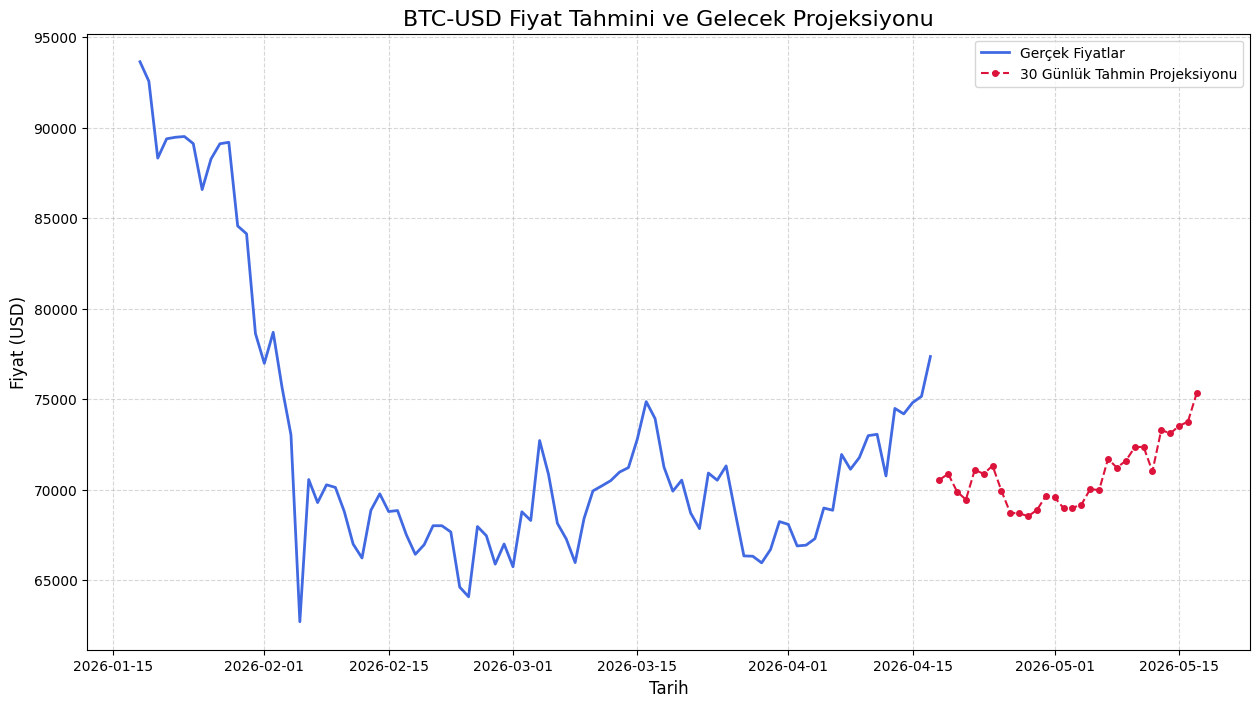

In [13]:
# 6. GÖRSELLEŞTİRME
plt.figure(figsize=(15, 8))

# Gerçek fiyatlar (Son 90 gün)
plt.plot(df.index[-90:], df['Close'][-90:], label='Gerçek Fiyatlar', color='royalblue', linewidth=2)

# Tahmin tarihlerini oluşturma (Gerçek verinin bittiği yerden başlatıyoruz)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=prediction_days + 1, freq='D')[1:]

# Tahminleri çizme
# Not: Kopukluğu gidermek için gerçek fiyatın son noktasını tahminin başına ekliyoruz
plt.plot(future_dates, prediction, label='30 Günlük Tahmin Projeksiyonu', color='crimson', linestyle='--', marker='o', markersize=4)

# Grafik detayları
plt.title(f'{ticker} Fiyat Tahmini ve Gelecek Projeksiyonu', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat (USD)', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()

In [14]:
# Modelin test başarısını yazdıralım
print(f"Model Test Skoru (R2): {model.score(xtest, ytest):.4f}")

Model Test Skoru (R2): 0.7691


In [15]:
from sklearn.metrics import mean_absolute_error

pred_test = model.predict(xtest)
print("MAE:", mean_absolute_error(ytest, pred_test))

MAE: 0.3542721647965629


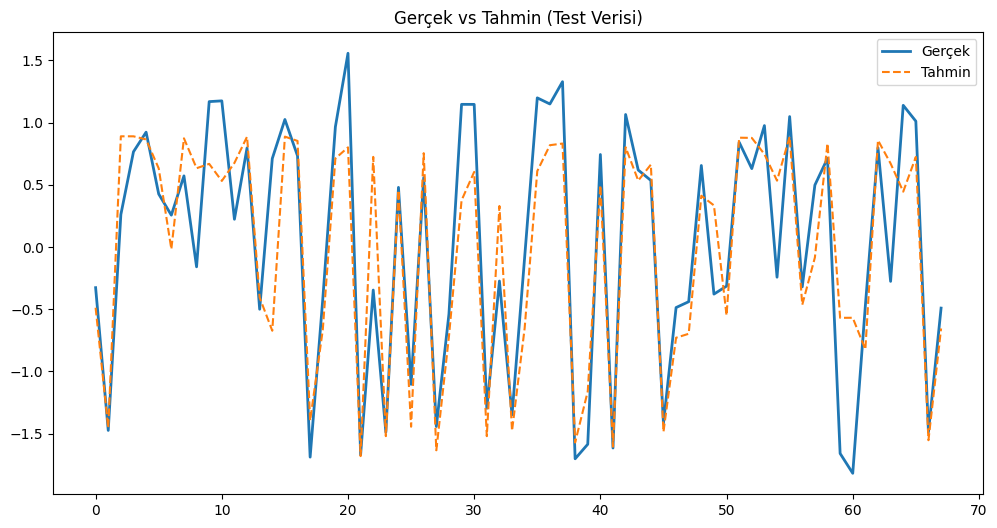

In [16]:
plt.figure(figsize=(12,6))
plt.plot(ytest, label="Gerçek", linewidth=2)
plt.plot(pred_test, label="Tahmin", linestyle="--")
plt.title("Gerçek vs Tahmin (Test Verisi)")
plt.legend()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(ytest, pred_test, alpha=0.5)
plt.xlabel("Gerçek")
plt.ylabel("Tahmin")
plt.title("Gerçek vs Tahmin Scatter")
plt.show()

## Conclusions

“Model works for trend detection but not precise prediction”

“Useful for analysis, not for direct trading decisions”

The results of this project indicate that the developed machine learning model was partially successful in capturing general trends in Bitcoin price movements. While the model demonstrated the ability to follow overall market direction, its accuracy in predicting sharp fluctuations and sudden price changes remained limited.

This outcome is expected, given the highly volatile and unpredictable nature of cryptocurrency markets. Despite these challenges, the model can still be considered useful for identifying broader trends and supporting analytical insights, rather than making precise trading decisions.

The inclusion of additional features such as moving averages and volatility improved performance, highlighting the importance of feature engineering. However, further improvements are necessary to increase reliability, particularly through the use of more advanced models and additional external data sources.

In conclusion, the model provides a valuable foundation for financial time series analysis, but it should be used with caution and not as a standalone decision-making tool in real-world trading scenarios.
